In [2]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# Set plotting style
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# LOAD IRIS DATASET

# Load the built-in Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Add readable species names
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

print("Iris dataset loaded successfully!")
print(f"Dataset contains {df.shape[0]} samples and {df.shape[1]} columns.")

Iris dataset loaded successfully!
Dataset contains 150 samples and 6 columns.


In [4]:
# Display first 10 rows

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


In [5]:
# DATASET INFORMATION


print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (150, 6)

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species               object
dtype: object


In [6]:
# CHECK FOR MISSING VALUES

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

if missing_values.sum() == 0:
    print("\n✓ No missing values found.")
else:
    print("\n⚠ Missing values detected.")

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

✓ No missing values found.


In [7]:
# DESCRIPTIVE STATISTICS
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Number of samples per species:
Setosa        50
Versicolor    50
Virginica     50
Name: species, dtype: int64


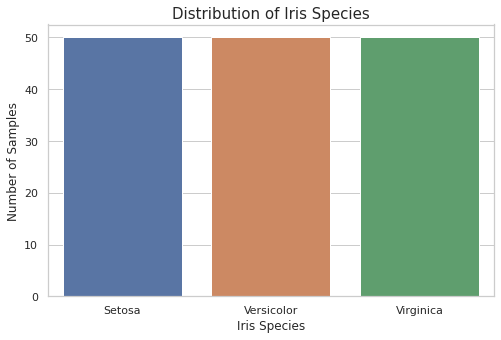

In [8]:
# CLASS DISTRIBUTION

print("Number of samples per species:")
print(df["species"].value_counts())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="species"
)

plt.title("Distribution of Iris Species", fontsize=15)
plt.xlabel("Iris Species")
plt.ylabel("Number of Samples")

plt.show()

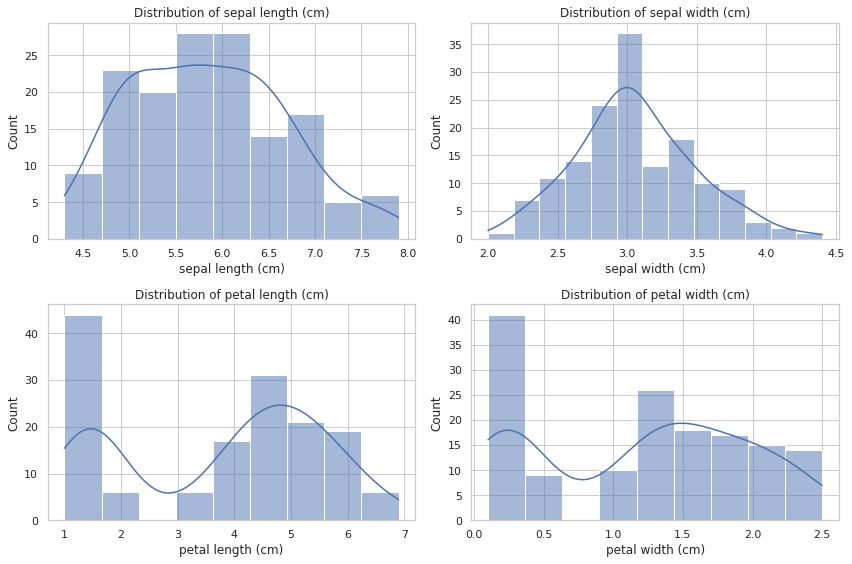

In [9]:
# FEATURE DISTRIBUTIONS

features = iris.feature_names

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

for ax, feature in zip(axes.ravel(), features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

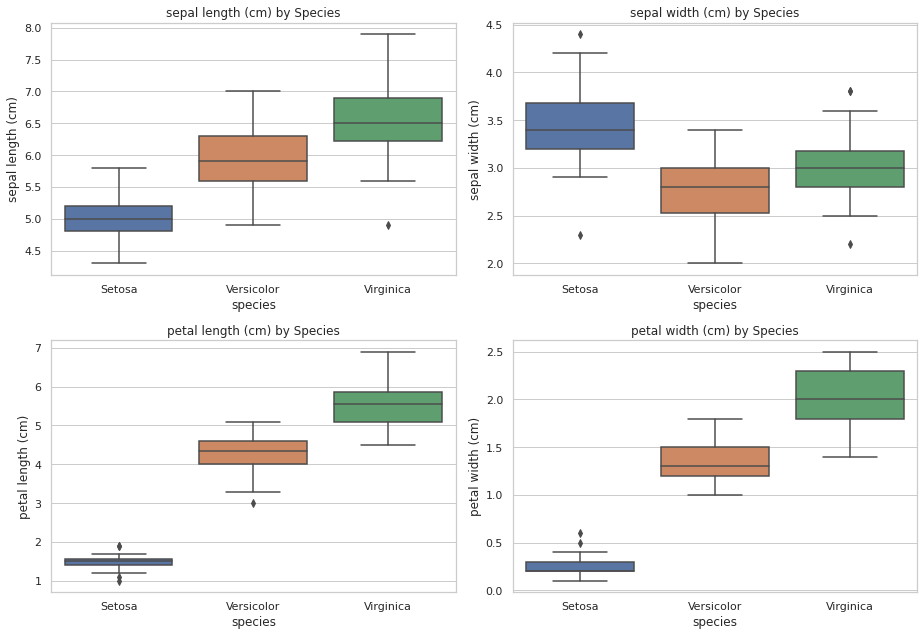

In [10]:
# BOX PLOTS

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 9)
)

for ax, feature in zip(axes.ravel(), features):

    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} by Species")

plt.tight_layout()
plt.show()

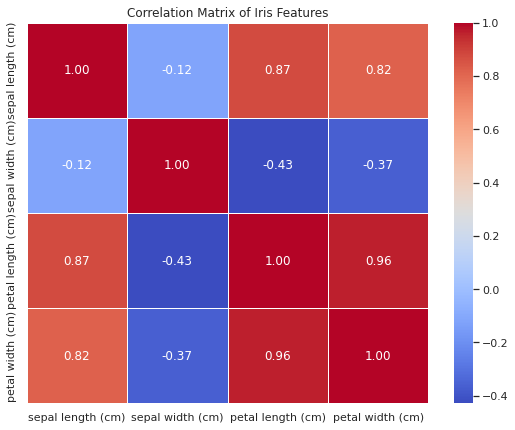

In [11]:
# CORRELATION MATRIX

correlation_matrix = df[features].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Iris Features")

plt.show()

In [12]:
# FEATURE SELECTION

X = df[features]
y = df["target"]

# Temporary Random Forest for feature importance
feature_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

feature_model.fit(X, y)

feature_importance = pd.Series(
    feature_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
petal length (cm)    0.436130
petal width (cm)     0.436065
sepal length (cm)    0.106128
sepal width (cm)     0.021678
dtype: float64


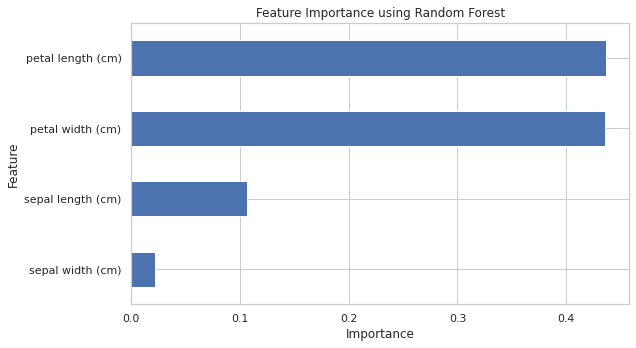

In [13]:
# FEATURE IMPORTANCE VISUALIZATION

plt.figure(figsize=(9, 5))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Feature Importance using Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [14]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training set size: (120, 4)
Testing set size : (30, 4)

Training class distribution:
0    40
1    40
2    40
Name: target, dtype: int64

Testing class distribution:
0    10
1    10
2    10
Name: target, dtype: int64


In [15]:
# FEATURE SCALING

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [16]:
# DEFINE CLASSIFICATION MODELS

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

print("Models initialized:")
for model_name in models:
    print("✓", model_name)

Models initialized:
✓ Logistic Regression
✓ K-Nearest Neighbors
✓ Decision Tree
✓ Random Forest


In [17]:
# 5-FOLD CROSS-VALIDATION

cv_results = []

for model_name, model in models.items():

    # Use scaled data for all models
    scores = cross_val_score(
        model,
        scaler.fit_transform(X),
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df["Mean CV Accuracy (%)"] = (
    cv_df["Mean CV Accuracy"] * 100
)

cv_df["Std CV Accuracy (%)"] = (
    cv_df["Std CV Accuracy"] * 100
)

cv_df

,Model,Mean CV Accuracy,Std CV Accuracy,Mean CV Accuracy (%),Std CV Accuracy (%)
0,Logistic Regression,0.960000,0.038873,96.000000,3.887301
1,K-Nearest Neighbors,0.960000,0.024944,96.000000,2.494438
2,Decision Tree,0.953333,0.033993,95.333333,3.399346
3,Random Forest,0.966667,0.021082,96.666667,2.108185


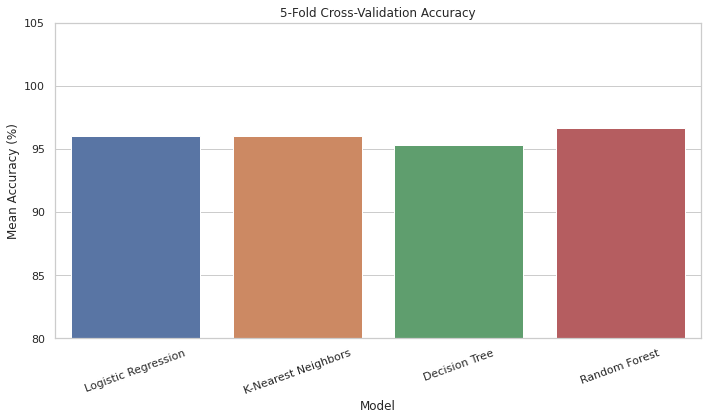

In [18]:
# CROSS-VALIDATION PERFORMANCE

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_df,
    x="Model",
    y="Mean CV Accuracy (%)"
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy (%)")
plt.ylim(80, 105)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [19]:
# TRAIN AND TEST MODELS

results = []
predictions = {}

for model_name, model in models.items():

    # Use scaled features
    model.fit(
        X_train_scaled,
        y_train
    )

    # Predict test data
    y_pred = model.predict(
        X_test_scaled
    )

    predictions[model_name] = y_pred

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,K-Nearest Neighbors,0.933333,0.944444,0.933333,0.932660
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
3,Random Forest,0.933333,0.933333,0.933333,0.933333


In [20]:
# CLASSIFICATION REPORTS

for model_name, y_pred in predictions.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=iris.target_names,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


K-Nearest Neighbors
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica      

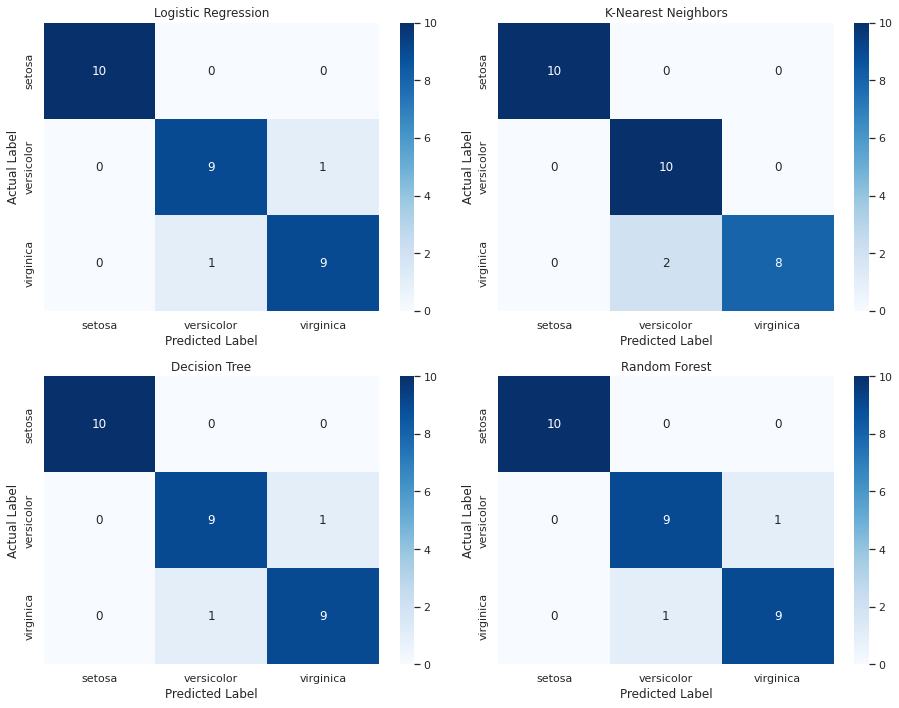

In [21]:
# CONFUSION MATRICES

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 10)
)

for ax, (model_name, y_pred) in zip(
    axes.ravel(),
    predictions.items()
):

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [25]:
# FINAL BEST MODEL

best_model = ranked_results.iloc[0]

print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

print(
    f"\nBest Performing Model: {best_model['Model']}"
)

print(
    f"Test Accuracy: {best_model['Accuracy'] * 100:.2f}%"
)

print(
    f"Precision: {best_model['Precision'] * 100:.2f}%"
)

print(
    f"Recall: {best_model['Recall'] * 100:.2f}%"
)

print(
    f"F1 Score: {best_model['F1 Score'] * 100:.2f}%"
)

print(
    f"Overall Score: {best_model['Overall Score'] * 100:.2f}%"
)

FINAL MODEL SELECTION

Best Performing Model: K-Nearest Neighbors
Test Accuracy: 93.33%
Precision: 94.44%
Recall: 93.33%
F1 Score: 93.27%
Overall Score: 93.59%


In [27]:
# CONCLUSION

best_model_name = best_model["Model"]

print(f"""
============================================================
FINAL CONCLUSION
============================================================

The Iris flower classification problem was successfully
implemented using four supervised machine learning algorithms:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest

The dataset was explored using descriptive statistics,
feature distributions, boxplots, pairplots and correlation
analysis.

An 80:20 train-test split was used for the final evaluation.
In addition, 5-fold cross-validation was performed to obtain
a more reliable estimate of model performance.

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Based on the combined evaluation metrics, the best-performing
model was:

{best_model_name}

The Iris dataset is relatively small and well-separated,
especially when using petal length and petal width. Therefore,
it is expected that multiple models may achieve very similar
performance.

The final model was selected based on the overall evaluation
rather than choosing a model solely because it is more complex.

Overall, the results demonstrate that supervised machine
learning algorithms can classify Iris flower species with
high accuracy using their sepal and petal measurements.
""")


FINAL CONCLUSION

The Iris flower classification problem was successfully
implemented using four supervised machine learning algorithms:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest

The dataset was explored using descriptive statistics,
feature distributions, boxplots, pairplots and correlation
analysis.

An 80:20 train-test split was used for the final evaluation.
In addition, 5-fold cross-validation was performed to obtain
a more reliable estimate of model performance.

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Based on the combined evaluation metrics, the best-performing
model was:

K-Nearest Neighbors

The Iris dataset is relatively small and well-separated,
especially when using petal length and petal width. Therefore,
it is expected that multiple models may achieve very similar
performance.

The final model was selected based on the overall evaluation
rather than choosing a model solely b